In [2]:
#Importing necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Loading the dataset
df = pd.read_csv(r"E:\Pyhton code\Data Sets\House Price\train (1).csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
#Checking the percentage of missing values in each column
missing_percentage = df.isnull().mean() * 100
missing_percentage.sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [ ]:
#Removing columns with more than 50% missing values
# df = df.dropna(thresh=len(df)*0.5, axis=1)

In [6]:
#Exploratory Data Analysis
df.describe()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

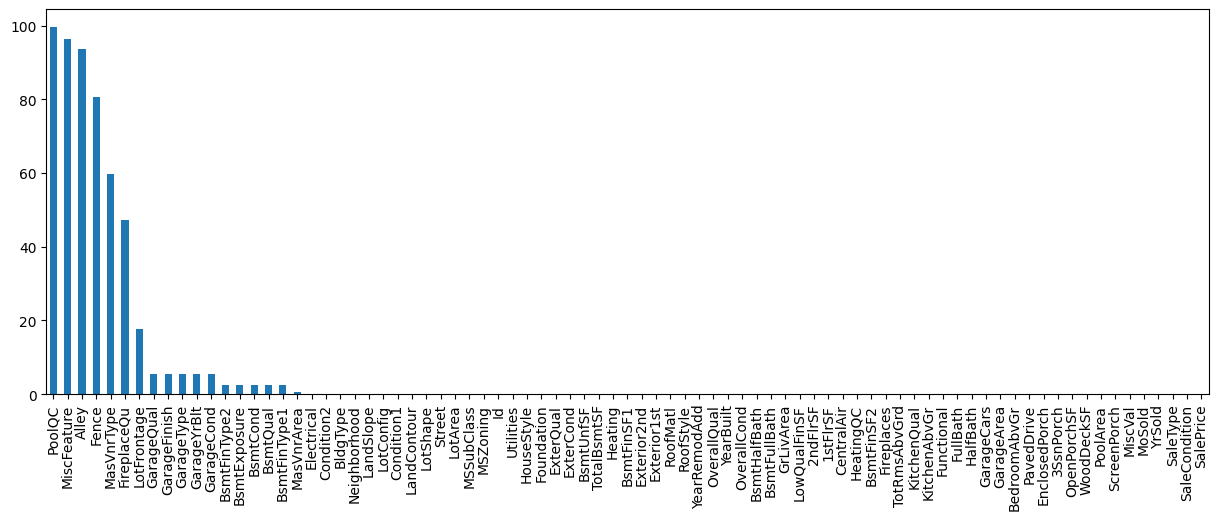

In [7]:
#Visualizing the percentage of missing values
missing_percentage.sort_values(ascending=False).plot(kind='bar', figsize=(15,5))
plt.show()

In [8]:
#Checking for duplicate rows
duplicate_count = df.duplicated().sum()
non_duplicate_count = len(df) - duplicate_count

print("Duplicate rows:", duplicate_count)
print("Non-Duplicate rows:", non_duplicate_count)

Duplicate rows: 0
Non-Duplicate rows: 1460


In [9]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
#Removing the 'Id' column as it is not useful for prediction
# df = df.drop('Id', axis=1)

In [14]:
#Separating features and target variable
x = df.drop("SalePrice", axis=1)
y = np.log1p(df["SalePrice"])

In [15]:
#Creating a new feature 'HouseAge' by calculating the difference between 'YrSold' and 'YearBuilt'
x['HouseAge'] = df['YrSold'] - df['YearBuilt']

In [16]:
#Identifying numerical and categorical columns
nums_cols = x.select_dtypes(include=['int64','float64']).columns
cat_cols = x.select_dtypes(include=['object']).columns

print("Numerical:", len(nums_cols))
print("Categorical:",len(cat_cols))

Numerical: 38
Categorical: 43


In [17]:
#Filling missing values in numerical columns with median
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
x[nums_cols] = num_imputer.fit_transform(x[nums_cols])

In [18]:
#Filling missing values in categorical columns with most frequent value
cat_imputer = SimpleImputer(strategy="most_frequent")
x[cat_cols] = cat_imputer.fit_transform(x[cat_cols])

In [19]:
#One-Hot Encoding- Converting categorical variables into dummy/indicator variables 
x = pd.get_dummies(x, drop_first=True)

In [20]:
#Getting the feature names after encoding (useful for later analysis)
feature_names = x.columns

In [21]:
#Tranform right_skewed data(SalePrice) using log transformation to make it more normally distributed
y = np.log1p(y)

In [22]:
#Splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
#Standardizing the numerical features to have mean=0 and variance=1 (important for many machine learning algorithms)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [24]:
#training a Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
#Predicting on the test set
y_pred = model.predict(x_test)

In [26]:
#Evaluating the model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 0.00026467067889514886
R-squared: 0.7601549027035601
Mean Absolute Error: 0.00753585357866309


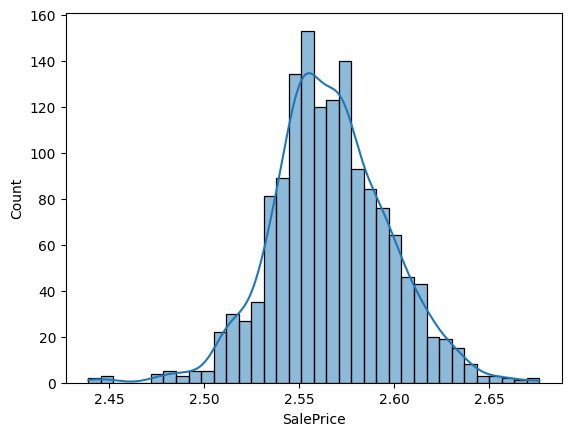

In [27]:
#Visualizing the distribution of the target variable 'SalePrice'
sns.histplot(y, kde=True)
plt.show()

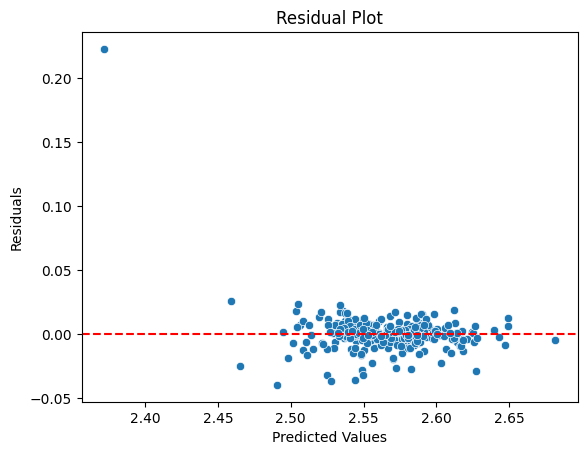

In [28]:
#Residual analysis to check the assumptions of linear regression
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [29]:
#Feature Importance(coefficients) from the Linear Regression model to see which features are most influential in predicting the target variable
importance = pd.Series(model.coef_, index=x_train.columns)
importance = importance.sort_values(key=abs, ascending=False)

importance.head(15)

RoofMatl_Metal      0.214396
RoofMatl_Roll       0.211405
RoofMatl_WdShngl    0.206594
RoofMatl_WdShake    0.206085
RoofMatl_CompShg    0.205505
RoofMatl_Tar&Grv    0.204702
Condition2_PosN    -0.059449
Condition2_RRAe    -0.033987
GarageCond_Po       0.032552
Functional_Sev     -0.032438
MiscFeature_TenC   -0.030441
GarageQual_Po      -0.030010
MSZoning_FV         0.029732
MSZoning_RH         0.029039
MSZoning_RL         0.027613
dtype: float64

In [30]:
#Checking for multicollinearity by calculating the correlation matrix and identifying highly correlated features (correlation > 0.85)
corr_matrix = x_train.corr().abs()

#upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

#find columns with correlation > 0.85
high_corr_cols = [
    column for column in upper.columns if any(upper[column]>0.85)
]

len(high_corr_cols)

15

In [31]:
#Removing highly correlated features to reduce multicollinearity and retraining the model to see if performance improves
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

print("R2 Score (Ridge):", r2_score(y_test, y_pred_ridge))

R2 Score (Ridge): 0.8950737251779914


In [32]:
#Trying Lasso Regression which can perform feature selection by shrinking some coefficients to zero, which can help in reducing multicollinearity and improving model interpretability
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(x_train, y_train)

y_pred_lasso = lasso.predict(x_test)

print("R2 Score (Lasso):", r2_score(y_test, y_pred_lasso))

R2 Score (Lasso): 0.8637672866505578


In [33]:
#Analyzing the coefficients from Lasso Regression to see which features were shrunk to zero (effectively removed from the model) and how many features were removed
lasso_importance = pd.Series(lasso.coef_, index=x_train.columns)
zero_features = (lasso_importance == 0).sum()

print("Number of features removed by Lasso:", zero_features)

Number of features removed by Lasso: 219


In [34]:
#Identifying the features that were not removed (non-zero coefficients) to see which features are still considered important by the Lasso model
lasso_importance = pd.Series(lasso.coef_, index=x_train.columns)

selected_features = lasso_importance[lasso_importance != 0].index

len(selected_features)

27

In [35]:
#Creating a new model using only the selected features from Lasso Regression to see if we can achieve similar or better performance with fewer features
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]

final_model = LinearRegression()
final_model.fit(x_train_selected, y_train)

y_pred_final = final_model.predict(x_test_selected)

print("Final R2 Score:",
      r2_score(y_test, y_pred_final))


Final R2 Score: 0.8686248549200315


Why Final R2 Score: Because we are using fewer features, we want to see if we can still achieve a good R2 score (close to the original model) while improving interpretability and reducing overfitting by removing less important features.

In [36]:
#Hyperparameter tuning for Lasso Regression using GridSearchCV to find the best alpha value that gives the best performance
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.0005, 0.001, 0.005, 0.01, 0.05]}

lasso_cv = GridSearchCV(Lasso(), param_grid, cv=5)
lasso_cv.fit(x_train, y_train)

print("Best alpha:", lasso_cv.best_params_)
print("Best R2:", lasso_cv.best_score_)

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.571e-03, tolerance: 8.420e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.969e-03, tolerance: 8.472e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

Best alpha: {'alpha': 0.0005}
Best R2: 0.82283016313908


In [37]:
#Using the best alpha value from GridSearchCV to train the final Lasso model and evaluate its performance on the test set
best_lasso = lasso_cv.best_estimator_
y_pred_best = best_lasso.predict(x_test)

print("Final Test R2:", r2_score(y_test, y_pred_best))

Final Test R2: 0.8701753713513295


In [38]:
#Performing cross-validation with the best Lasso model to get a more robust estimate of its performance and check for overfitting or underfitting
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_lasso, x, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", scores)
print("Mean CV R2:", scores.mean())

Cross-validation R2 scores: [0.90929488 0.86839985 0.87305452 0.8890825  0.75853649]
Mean CV R2: 0.859673650001082


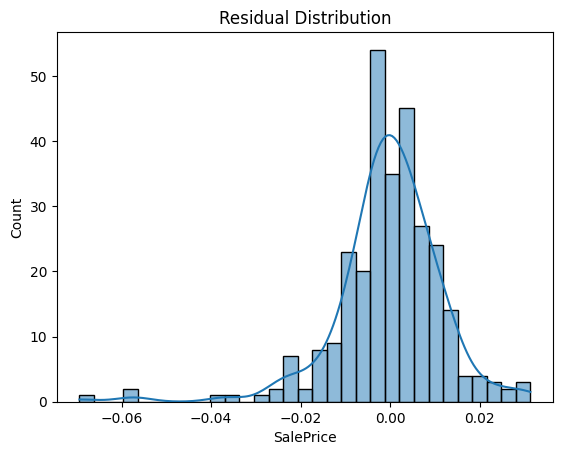

In [39]:
#Visualizing the residuals of the best Lasso model to check for patterns and see if the model is fitting well (ideally should be randomly distributed around zero)
residuals = y_test - y_pred_best

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

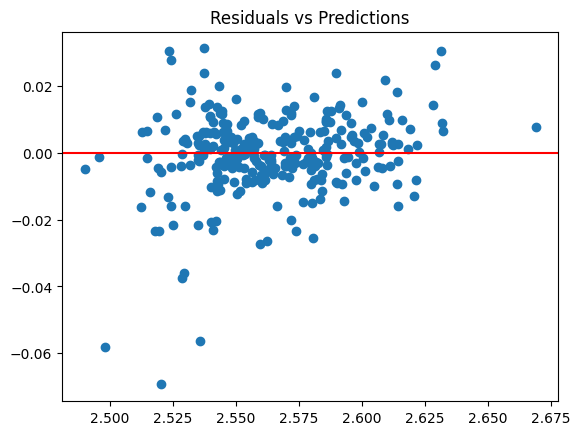

In [40]:
#Visualizing the residuals vs predictions to check for patterns (ideally should be randomly distributed around zero with no clear pattern)
plt.scatter(y_pred_best, residuals)
plt.axhline(y=0, color='r')
plt.title("Residuals vs Predictions")
plt.show()

In [41]:
#Converting the predicted and actual values back to the original scale by applying the inverse of the log transformation (exponential) to interpret the results in terms of actual house prices
y_pred_actual = np.expm1(y_pred_best)
y_test_actual = np.expm1(y_test)

In [48]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

from sklearn.metrics import mean_absolute_error

print("MAE actual scale:",
      mean_absolute_error(y_test_actual, y_pred_actual))

MAE actual scale: 0.09649885519468826


In [43]:
#Analyzing the errors in terms of actual prices to see which predictions had the largest deviations from the actual prices and if there are any patterns in those errors (e.g., are we underpredicting expensive houses or overpredicting cheap houses?)
errors = abs(y_test_actual - y_pred_actual)
errors.sort_values(ascending=False).head(10)

30      0.833346
812     0.693151
916     0.686885
1432    0.460013
874     0.442176
898     0.431680
1170    0.401934
277     0.385124
1046    0.370802
669     0.351335
Name: SalePrice, dtype: float64

In [44]:
#Featur Interpretation(importance) from the best Lasso model to see which features are most influential in predicting the target variable after hyperparameter tuning and feature selection
lasso_importance = pd.Series(best_lasso.coef_, index=x_train.columns)
lasso_importance = lasso_importance.sort_values(key=abs, ascending=False)

lasso_importance.head(15)

OverallQual         0.006312
OverallCond         0.002956
Fireplaces          0.002530
GarageCars          0.001542
BsmtFullBath        0.001346
MSZoning_RM        -0.000856
TotRmsAbvGrd        0.000565
BsmtExposure_No    -0.000517
Condition1_Norm     0.000374
HouseAge           -0.000273
YearRemodAdd        0.000141
Foundation_PConc    0.000118
GarageYrBlt        -0.000061
MSSubClass         -0.000056
BsmtFinType1_Unf   -0.000050
dtype: float64

In [45]:
#Since the coefficients from Lasso are in log scale (because we log-transformed the target variable), we can exponentiate them to interpret the importance in terms of actual price changes. A coefficient of 0.1 would mean that a one unit increase in that feature is associated with approximately a 10% increase in the predicted price, while a coefficient of -0.1 would mean a 10% decrease.
np.exp(lasso_importance.head(10))

OverallQual        1.006332
OverallCond        1.002960
Fireplaces         1.002533
GarageCars         1.001543
BsmtFullBath       1.001347
MSZoning_RM        0.999144
TotRmsAbvGrd       1.000565
BsmtExposure_No    0.999483
Condition1_Norm    1.000374
HouseAge           0.999727
dtype: float64

In [46]:
#Saving the best Lasso model and the scaler to a file using pickle for later use in making predictions on new data without having to retrain the model
import pickle

pipeline_data = {
    "model": best_lasso,
    "scaler": scaler,
    "feature_names": feature_names
}

with open("house_price_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline_data, f)

In [47]:
#Function to load the saved model and make predictions on new data
def predict_price(new_data):
    new_data = pd.get_dummies(new_data)
    new_data = new_data.reindex(columns=feature_names, fill_value=0)
    new_data = scaler.transform(new_data)
    prediction_log = best_lasso.predict(new_data)
    return np.expm1(prediction_log)

```Problem:```
Predict house prices using regression.

```Dataset:```
Kaggle House Prices.

```Steps:```
1) Data cleaning
2) Encoding
3) Scaling
4) Baseline model
5) Ridge & Lasso
6) Hyperparameter tuning

```Final Model:```
Lasso Regression

```Final Performance:```
1) Test R²: 0.8926
2) CV R²: 0.8643
3) MAE: ~16,762 (~9% error)